In this notebook I walk through example subjects (chemistry & specialist math) of training a sentence transformer model to get an idea of what kind of models might be successful/perform the best in general, and the optimal training procedures, pretrained model to use etc.

In [1]:
import sys
from pathlib import Path

parent_dir = str(Path().resolve().parents[0])
sys.path.insert(0, parent_dir)

In [2]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from InstructorEmbedding import INSTRUCTOR

from src.paths import DATA_DIR
from src.Qlassifier.utils import prepare_dataframes
from src.Qlassifier.prediction import get_predictions
from src.Qlassifier.evaluation import evaluate_predictions, plot_conf

/home/ykip10/projects/Qlassifier/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model = SentenceTransformer("intfloat/e5-base-v2") # https://huggingface.co/intfloat/e5-base-v2
model2 = INSTRUCTOR('hkunlp/instructor-large') # https://huggingface.co/hkunlp/instructor-large

No sentence-transformers model found with name hkunlp/instructor-large. Creating a new one with mean pooling.


We try two models: one without explicit instructions, and one with. Instructions typically help with domain-specific NLP tasks, like this one. 

# Scope

In [4]:
subjects = [
    "chemistry",
    "specialist_mathematics"
]
subject1 = subjects[0]
chem = "2023"
chem_dir = DATA_DIR / subject1 / "past_exams"
chem_path = chem_dir / f"{chem}.pdf"

subject2 = subjects[1]
math = "2023_2"
math_dir = DATA_DIR / subject2 / "past_exams"
math_path = math_dir / f"{math}.pdf"

# Sentence Transformer

## Chem

In [5]:
qn_df, sd_df = prepare_dataframes(chem_path, subject=subject1, load_report=True) 

/home/ykip10/projects/Qlassifier/src/Qlassifier/utils.py:85: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~(sd_df["label"].str.contains(


In [6]:
sd_df.head(5)

,label,text
0,Carbon-based fuels,"the definition of a fuel, including the disti..."
1,Measuring changes in chemical reactions,calculations related to the application of st...
2,Primary galvanic cells and fuel cells as sourc...,redox reactions as simultaneous oxidation and...
3,Rates of chemical reactions,factors affecting the frequency and success o...
4,Extent of chemical reactions,the distinction between reversible and irreve...


In [7]:
qn_df.head(5)

,label,text,comments,total_marks
0,Question 1,Which one of the following correctly represent...,"In human cells, glucose reacts with oxygen in ...",1
1,Question 2,Which one of the following statements is corre...,Fuel cells and galvanic cells both produce hea...,1
2,Question 3,"Molecules X, and all have the same number of c...",The larger the number of C=C double bonds in t...,1
3,Question 4,cell can be considered secondary cell if A. it...,The polarity of the physical electrodes does n...,1
4,Question 5,Consider the following statements about coenzy...,All three statements are properties of coenzym...,1


### Predictions & Evaluation

We only hand-label one exam (per subject analysed in this notebook) for evaluation purposes. This means evaluation is really quite limited.

In [8]:
true_topic_mcq = [
    0, 2, 6, 5, 10, 9, 0, 4, 0, 4,
    3, 3, 6, 4, 0, 9, 1, 9, 6, 8,
    10 ,2, 6, 2, 5, 11, 12, 2, 9, 2,
]

true_topic_indices = true_topic_mcq + [
    6, 7, 7, 6, 6, 2, 2, 2, 2,   # Q1
    6, 10, 10, 10, 6, 10, 6, 10, # Q2
    0, 0, 0, 0, 0, 6,            # Q3
    7, 6, 7, 7, 7,               # Q4
    0, 4, 4, 3,                  # Q5
    2, 2, 2, 2, 2,               # Q6 
    9, 9, 9, 9, 9,               # Q7
    3, 12, 12, 1, 1, 11, 11, 11, # Q8
    5, 5                         # Q9
]

Let's visualise the model output.

In [97]:
pred_df, cos_qn, cos_rp  = get_predictions(
    qn_df, sd_df, model=model, subject=subject1, labels=true_topic_indices, 
)
pred_df.head(5)

,label,text,pred_topic,pred_topic_idx,report_pred,true_topic_idx,true_topic,confidence
0,Question 1,Which one of the following correctly represent...,Carbon-based fuels,0,0,0,Carbon-based fuels,0.516132
1,Question 2,Which one of the following statements is corre...,Primary galvanic cells and fuel cells as sourc...,2,0,2,Primary galvanic cells and fuel cells as sourc...,1.000000
2,Question 3,"Molecules X, and all have the same number of c...","Structure, nomenclature and properties of orga...",6,0,6,"Structure, nomenclature and properties of orga...",0.238871
3,Question 4,cell can be considered secondary cell if A. it...,Primary galvanic cells and fuel cells as sourc...,2,0,5,Production of chemicals using electrolysis,0.707216
4,Question 5,Consider the following statements about coenzy...,Reactions of organic compounds,7,0,10,Medicinal chemistry,0.096104


Predictions by the report and predictions directly by question text seem to go hand-in-hand, even when they are both wrong, which is interesting. 

Let's get some high-level sense of how accurate our model is. 

In [14]:
evaluate_predictions(pred_df, cos_qn, cos_rp)

--EVAL METRICS--
pred_topic_idx accuracy: 43.90%
report_pred accuracy: 12.20%
The percent of time either report_pred or pred_topic_idxlabels a question correctly is 48.78%
% of time the true topic in top 3 report_pred prediction: 24.39%
% of time the true topic in top 3 pred_topic_idx prediction: 75.61%


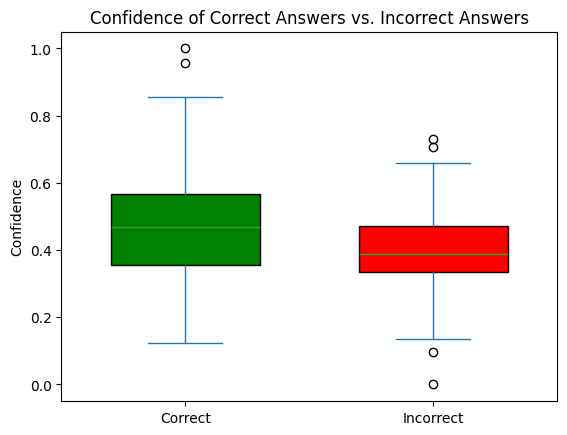

In [15]:
plot_conf(pred_df)

What about just the MCQ section? Perhaps the model underperforms on short answer questions.

In [19]:
mcq_df, cos_qn_mcq, cos_rp_mcq = get_predictions(
    qn_df, sd_df, model=model, subject=subject1, labels=true_topic_mcq
) 

evaluate_predictions(mcq_df, cos_qn_mcq, cos_rp_mcq)

--EVAL METRICS--
pred_topic_idx accuracy: 60.00%
report_pred accuracy: 13.33%
The percent of time either report_pred or pred_topic_idxlabels a question correctly is 60.00%
% of time the true topic in top 3 report_pred prediction: 16.67%
% of time the true topic in top 3 pred_topic_idx prediction: 90.00%


Indeed, the model finds it easier to classify MCQ questions. Why?

In [20]:
pred_df.loc[30:].tail(10)

,label,text,pred_topic,pred_topic_idx,report_pred,true_topic_idx,true_topic,confidence
72,Question 8a.,student performed an experiment to compare the...,Measuring changes in chemical reactions,1,0,3,Rates of chemical reactions,0.257243
73,Question 8b.,student performed an experiment to compare the...,Measuring changes in chemical reactions,1,0,12,Investigation design,0.300307
74,Question 8c.,student performed an experiment to compare the...,Measuring changes in chemical reactions,1,0,12,Investigation design,0.274689
75,Question 8d.,student performed an experiment to compare the...,Measuring changes in chemical reactions,1,0,1,Measuring changes in chemical reactions,0.326326
76,Question 8e.i.,student performed an experiment to compare the...,Measuring changes in chemical reactions,1,0,1,Measuring changes in chemical reactions,0.406727
77,Question 8e.ii.,student performed an experiment to compare the...,Measuring changes in chemical reactions,1,0,11,How is scientific inquiry used to investigate ...,0.380233
78,Question 8f.,student performed an experiment to compare the...,Measuring changes in chemical reactions,1,0,11,How is scientific inquiry used to investigate ...,0.288923
79,Question 8g.,student performed an experiment to compare the...,Measuring changes in chemical reactions,1,0,11,How is scientific inquiry used to investigate ...,0.292136
80,Question 9a.,Purified copper contains at least 99.8% copper...,Production of chemicals using electrolysis,5,0,5,Production of chemicals using electrolysis,0.823630
81,Question 9b.,"Explain how the Faraday constant, together wit...",Production of chemicals using electrolysis,5,0,5,Production of chemicals using electrolysis,0.531527


We can already see that this is probably a problem with how we chose to represent the question text that the model just cannot adapt to. For every subquestion, we chose to concatenate the text of the context. This is good in that it has a tendency to group subquestions together (which is a real pattern in examinations; subquestions often relate to each other), but the link seems to be too strong in that it also leads to erroneous homogeneity.

But without it, how would we ever classify part b) of a question whose only text is "Justify your answer"? 


On another note: Perhaps we can combine the model's predictions using the report and question in some way to models accuracy.
It should be noted that combining exam and report into one query to the model has been tried, but does not lead to increases in performance.

### Fine-tuning with SimCSE

SimCSE is an unsupervised learning algorithm that works by taking the same sentence twice, introducing dropout noise, then, based on the fact that these two features should be close together in embedding space, optimises a loss. 

We should see if we can improve the model by fine tuning it.

In [14]:
from sentence_transformers import losses
from torch.utils.data import DataLoader
from sentence_transformers import InputExample

In [15]:
training_exam_dfs = []
training_report_dfs = []

for exam_path in chem_dir.iterdir():
    if chem in str(exam_path):
        # leave current dataset for evaluation
        continue
    curr_exam = exam_path.stem
    train_exam_df, train_report_df, _ = prepare_dataframes(exam_path)
    train_exam_df.insert(0, "Exam Year", [curr_exam]*len(train_exam_df))
    train_report_df.insert(0, "Exam Year", [curr_exam]*len(train_report_df))

    training_exam_dfs.append(train_exam_df)
    training_report_dfs.append(train_report_df)

/home/ykip10/projects/Qlassifier/src/Qlassifier/utils.py:74: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~(sd_df["label"].str.contains(


ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
# ["Exam Year", "Label"] unique for each year
training_ex_df = pd.concat(training_exam_dfs) \
                   .reset_index(drop=True) \
                   .drop_duplicates(subset=["Exam Year", "label"])

training_rp_df = pd.concat(training_report_dfs) \
                   .reset_index(drop=True) \
                   .rename({"comments": "text"}, axis=1) \
                   .fillna(value="")

ex_train_examples = [InputExample(texts=[s, s]) for s in training_ex_df["text"]]
rp_train_examples = [InputExample(texts=[s, s]) for s in training_rp_df["text"]]

ex_dataloader = DataLoader(ex_train_examples, shuffle=True, batch_size=32)

loss = losses.MultipleNegativesRankingLoss(model)
model.fit(train_objectives=[(ex_dataloader, loss)], epochs=1)

Step,Training Loss


In [ ]:
preds = get_predictions(qn_df, sd_df, true_topic_indices)

,label,text,input,predicted_topic,predicted_topic_idx,report_predict,true_topic_idx,true_topic
0,Question 1,Which one of the following correctly represent...,Which one of the following correctly represent...,Carbon-based fuels,0,0,0,Carbon-based fuels
1,Question 2,Which one of the following statements is corre...,Which one of the following statements is corre...,Primary galvanic cells and fuel cells as sourc...,2,2,2,Primary galvanic cells and fuel cells as sourc...
2,Question 3,"Molecules X, and all have the same number of c...","Molecules X, and all have the same number of c...","Structure, nomenclature and properties of orga...",6,6,6,"Structure, nomenclature and properties of orga..."
3,Question 4,cell can be considered secondary cell if A. it...,cell can be considered secondary cell if A. it...,Primary galvanic cells and fuel cells as sourc...,2,2,5,Production of chemicals using electrolysis
4,Question 5,Consider the following statements about coenzy...,Consider the following statements about coenzy...,Reactions of organic compounds,7,7,10,Medicinal chemistry
5,Question 6,Consider the following statements. I. HPLC is ...,Consider the following statements. I. HPLC is ...,Laboratory analysis of organic compounds,8,9,9,Instrumental analysis of organic compounds
6,Question 7,Consider the following statements about fossil...,Consider the following statements about fossil...,Carbon-based fuels,0,0,0,Carbon-based fuels
7,Question 8,"At 327 °C, the equilibrium constant for the re...","At 327 °C, the equilibrium constant for the re...",Extent of chemical reactions,4,4,4,Extent of chemical reactions
8,Question 9,Consider the following statements about coal s...,Consider the following statements about coal s...,Carbon-based fuels,0,0,0,Carbon-based fuels
9,Question 10,"At constant temperature, which one of the foll...","At constant temperature, which one of the foll...",Extent of chemical reactions,4,4,4,Extent of chemical reactions


In [ ]:
evaluate_predictions(preds)

The accuracy here is about 66% (I forgot to compute in python, I closed my IDE, do not want to re-train model).

Yeah so clearly our approach is wrong. It doesn't make sense to train the model to look for semantic similarities using SimCSE because two questions belonging to two different topics can be semantically similar (Such as "Calculate the ... of ..."), so an embedding space which doesn't bring together two similar topics doesn't help us.  

## Specialist Math

Next, I want to check how the model works on the specialist mathematics exams. Without customising, for the same reason as above.

Let's just use the same model and approach. We learnt that there's really no benefit to fine-tuning (on this model, for this task, with our data), so we won't waste time doing that. 

In [22]:
mcq_labels = [
    0, 1, 1, 2, 2, 4, 4, 4, 7, 3, 
    3, 5, 5, 6, 6, 8, 6, 7, 9, 11,
]

ground_truth = mcq_labels + [
    1, 3, 3, 3, 7, 8, 3, 3,            # Q1
    2, 2, 2, 2, 2, 2, 2, 2,            # Q2
    3, 3, 3, 3, 3, 3,                  # Q3
    4, 4, 4, 4, 4, 4, 1, 4,            # Q4
    6, 6, 7, 7, 7, 7,                  # Q5
    11, 11, 11, 12, 12, 12, 12, 12, 10 # Q6  

]

qn_df_math, sd_df_math = prepare_dataframes(math_path, subject=subject2)
pred_df_math, cos_qn_math, cos_rp_math  = get_predictions(
    qn_df_math, sd_df_math, model=model, subject=subject2, labels=ground_truth
)

In [23]:
evaluate_predictions(pred_df_math, cos_qn_math, cos_rp_math)

--EVAL METRICS--
pred_topic_idx accuracy: 52.31%
report_pred accuracy: 6.15%
The percent of time either report_pred or pred_topic_idxlabels a question correctly is 53.85%
% of time the true topic in top 3 report_pred prediction: 24.62%
% of time the true topic in top 3 pred_topic_idx prediction: 80.00%


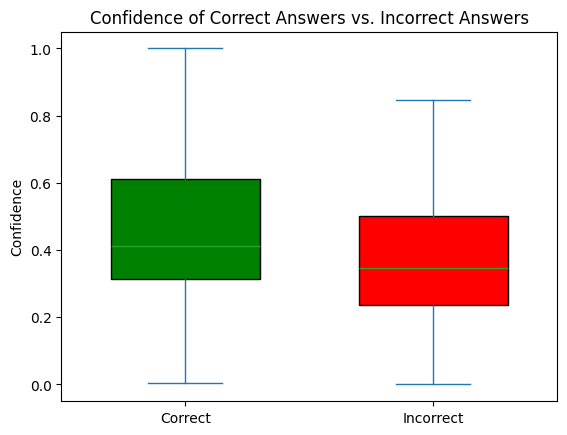

In [24]:
plot_conf(pred_df_math)

Check MCQ only performance

In [26]:
mcq_df_math, cos_qn_math_mcq, cos_rp_math_mcq  = get_predictions(
    qn_df_math, sd_df_math, model=model, subject=subject2, labels=mcq_labels
)

evaluate_predictions(mcq_df_math, cos_qn_math_mcq, cos_rp_math_mcq)

--EVAL METRICS--
pred_topic_idx accuracy: 70.00%
report_pred accuracy: 10.00%
The percent of time either report_pred or pred_topic_idxlabels a question correctly is 70.00%
% of time the true topic in top 3 report_pred prediction: 35.00%
% of time the true topic in top 3 pred_topic_idx prediction: 85.00%


The report comments are mostly empty for these mcq questions. We note that if this is the case, the report's predictions should be weighed very lightly. For the chemistry case, where the report text is dense, the reports seem to capture some patterns uncaptured by the exam questions.

Also, we learnt that this model actually performs substantially better in the mathematics (at least on this limited, small mcq only dataset) when compared to the TF-IDF approach (although still not great). 

Another thing: the report is too inconsistent to actually be used effectively. Even in the most extreme case (chemistry, every question has paragraphs of comments) there is little benefit. It adds an extra layer of complexity for no reason. 

# Instructor

## Chem

In [9]:
pred_df2, cos_qn2, cos_rp2  = get_predictions(
    qn_df, sd_df, model=model2, subject=subject1, labels=true_topic_indices
)
pred_df2.head(5)

`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.


,label,text,comments,total_marks,pred_topic,pred_topic_idx,report_pred,true_topic_idx,true_topic,confidence
0,Question 1,Which one of the following correctly represent...,"In human cells, glucose reacts with oxygen in ...",1,Carbon-based fuels,0,0,0,Carbon-based fuels,0.357521
1,Question 2,Which one of the following statements is corre...,Fuel cells and galvanic cells both produce hea...,1,Primary galvanic cells and fuel cells as sourc...,2,2,2,Primary galvanic cells and fuel cells as sourc...,0.871548
2,Question 3,"Molecules X, and all have the same number of c...",The larger the number of C=C double bonds in t...,1,"Structure, nomenclature and properties of orga...",6,6,6,"Structure, nomenclature and properties of orga...",0.413326
3,Question 4,cell can be considered secondary cell if A. it...,The polarity of the physical electrodes does n...,1,Primary galvanic cells and fuel cells as sourc...,2,2,5,Production of chemicals using electrolysis,0.626425
4,Question 5,Consider the following statements about coenzy...,All three statements are properties of coenzym...,1,Rates of chemical reactions,3,3,10,Medicinal chemistry,0.412809


In [10]:
evaluate_predictions(pred_df2, cos_qn2)

--EVAL METRICS--
pred_topic_idx accuracy: 46.34%
% of time the true topic in top 3 pred_topic_idx prediction: 79.27%


This model does perform slightly better on the short answer. What about MCQ?

In [ ]:
mcq_df2, cos_qn_mcq2, cos_rp_mcq2 = get_predictions(
    qn_df, sd_df, model=model2, subject=subject1, labels=true_topic_mcq
) 
evaluate_predictions(mcq_df, cos_qn_mcq)

`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.


Marginal improvements, if any. 

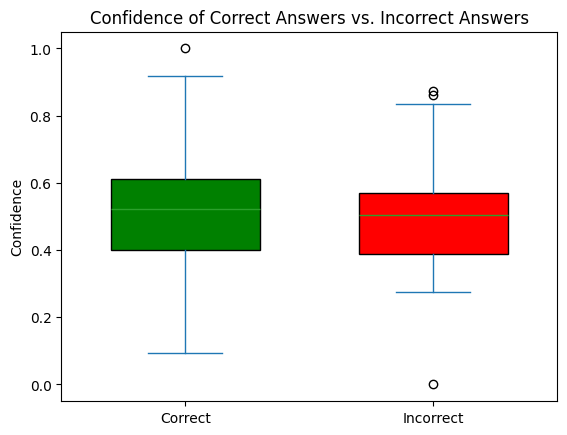

In [30]:
plot_conf(pred_df2)

Let's see if the instructor vs sentence transformer models are learning different things (so we may be able to combine their predictions)! 

In [31]:
pred_df2 = pred_df2.rename({"pred_topic_idx": "instructor_pred"}, axis=1)
pred_df2["sentence_tr_pred"] = pred_df["pred_topic_idx"]

evaluate_predictions(
    pred_df2,
    cos_qn2,
    cos_qn,
    pred_cols = ["instructor_pred", "sentence_tr_pred"]
)

--EVAL METRICS--
instructor_pred accuracy: 47.56%
sentence_tr_pred accuracy: 43.90%
The percent of time either sentence_tr_pred or instructor_predlabels a question correctly is 59.76%
% of time the true topic in top 3 sentence_tr_pred prediction: 75.61%
% of time the true topic in top 3 instructor_pred prediction: 79.27%


It appears there may be some potential gain in merging the two predictions.

## Math

In [ ]:
pred_df_math2, cos_qn_math2, cos_rp_math2  = get_predictions(
    qn_df_math, sd_df_math, model=model2, subject=subject1, labels=ground_truth
)

`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.


In [51]:
evaluate_predictions(pred_df_math2, cos_qn_math2)

--EVAL METRICS--
pred_topic_idx accuracy: 81.54%
% of time the true topic in top 3 pred_topic_idx prediction: 93.85%


These are quite massive improvements over the previous model. And the MCQ section in particular?

In [50]:
mcq_df_math2, cos_qn_math_mcq2, cos_rp_math_mcq2  = get_predictions(
    qn_df_math, sd_df_math, labels=mcq_labels, model=model2, subject="Mathematics", instruct=True
)

evaluate_predictions(mcq_df_math2, cos_qn_math_mcq2)

`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.


--EVAL METRICS--
pred_topic_idx accuracy: 75.00%
% of time the true topic in top 3 pred_topic_idx prediction: 100.00%


The MCQ section improved as well, but its the short answer questions which have been massively improved.

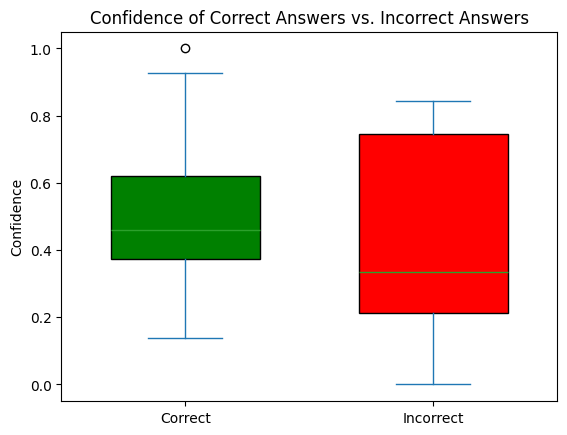

In [52]:
plot_conf(pred_df_math2)

We get this plot because there are very little incorrect answers. 

The instructor model performs far better for mathematics than the purely sentence-transformer one. Let's check to see if there is any differences in their predictions (perhaps they capture different trends?)

In [53]:
pred_df_math2 = pred_df_math2.rename({"pred_topic_idx": "instructor_pred"}, axis=1)
pred_df_math2["sentence_tr_pred"] = pred_df_math["pred_topic_idx"]

In [54]:
evaluate_predictions(
    pred_df_math2,
    cos_qn_math2,
    cos_qn_math,
    pred_cols = ["instructor_pred", "sentence_tr_pred"]
)

--EVAL METRICS--
instructor_pred accuracy: 81.54%
sentence_tr_pred accuracy: 52.31%
The percent of time either sentence_tr_pred or instructor_predlabels a question correctly is 83.08%
% of time the true topic in top 3 sentence_tr_pred prediction: 80.00%
% of time the true topic in top 3 instructor_pred prediction: 93.85%


Doesn't look like there is much to be gained here. 

# Combining Instructor with TF-IDF

It seems like there might be a benefit to combining the INSTRUCTOR predictions with the TF-IDF,

In [89]:
from src.Qlassifier.prediction import run_combined

cos = run_combined(
    chem_path, subject1, tf_idf_weight=0.3, model=model2
)[2]
preds = cos.argmax(dim=1).tolist()
pred_df_combined = pred_df2.copy()
pred_df_combined["combined_pred"] = preds

/home/ykip10/projects/Qlassifier/src/Qlassifier/utils.py:81: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~(sd_df["label"].str.contains(
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
/home/ykip10/projects/Qlassifier/src/Qlassifier/utils.py:81: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~(sd_df["label"].str.contains(


In [91]:
evaluate_predictions(pred_df_combined, cos1=cos, cos2=cos_qn2, pred_cols = ["combined_pred", "instructor_pred"])

--EVAL METRICS--
combined_pred accuracy: 51.22%
instructor_pred accuracy: 47.56%
The percent of time either instructor_pred or combined_predlabels a question correctly is 52.44%
% of time the true topic in top 3 instructor_pred prediction: 79.27%
% of time the true topic in top 3 combined_pred prediction: 79.27%


Negligible improvements here. Try math.

In [87]:
cos_math = run_combined(
    math_path, subject2, tf_idf_weight=0.1, model=model2
)[2]
preds = cos_math.argmax(dim=1).tolist()
pred_df_combined_math = pred_df_math2.copy()
pred_df_combined_math["combined_pred"] = preds

`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.


In [88]:
evaluate_predictions(
    pred_df_combined_math,
    cos1=cos_math,
    cos2=cos_qn_math2,
    pred_cols = ["combined_pred", "instructor_pred"]
)

--EVAL METRICS--
combined_pred accuracy: 78.46%
instructor_pred accuracy: 81.54%
The percent of time either instructor_pred or combined_predlabels a question correctly is 81.54%
% of time the true topic in top 3 instructor_pred prediction: 93.85%
% of time the true topic in top 3 combined_pred prediction: 92.31%


This makes sense. The TF-IDF approach is horrible for these latex-heavy mathematics subjects, so combining just hurts the instructor model. 

# Export

In [94]:
pred_df_math2.to_csv(Path("results") / "model2_math.csv")
pred_df2.to_csv(Path("results") / "model2_chem.csv")